# Logistic Regression

## What is Logistic Regression?

Logistic Regression answers: *"Given these features, what is the probability this sample belongs to class 1?"*

It uses the **sigmoid function** to squash a linear score into a probability:

$$P(y=1 \mid \mathbf{x}) = \sigma(z) = \frac{1}{1+e^{-z}}, \quad z = \mathbf{w} \cdot \mathbf{x} + b$$

## Why Not Just Use Linear Regression for Classification?

Linear regression can predict values outside [0, 1], which is meaningless for probabilities and causes instability near the boundaries. The sigmoid function solves this by mapping any real number to a valid probability.

## Loss Function

**Binary cross-entropy** penalizes confident wrong predictions exponentially:

$$\mathcal{L} = -\frac{1}{n}\sum\left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]$$

If the model predicts $\hat{p} = 0.99$ but the true label is $y = 0$, the loss is $-\log(0.01) \approx 4.6$ , a large penalty.

---
**Dataset:** Breast Cancer Wisconsin  
**Task:** Predict malignant (1) vs benign (0) tumor

## 1. Setup & Data Export

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.logistic_regression import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Export dataset to CSV
CSV_PATH = 'breast_cancer.csv'
if not os.path.exists(CSV_PATH):
    bc = load_breast_cancer()
    df_export = pd.DataFrame(bc.data, columns=bc.feature_names)
    df_export['target'] = bc.target
    df_export.to_csv(CSV_PATH, index=False)
    print('Dataset exported to CSV.')
else:
    print('Dataset already present.')

Dataset exported to CSV.


## 2. Data Exploration

In [2]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nClass distribution:')
print(df['target'].value_counts().rename({1: 'Benign', 0: 'Malignant'}))
df.head()

Shape: (569, 31)

Class distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Top 10 features by correlation with target:
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


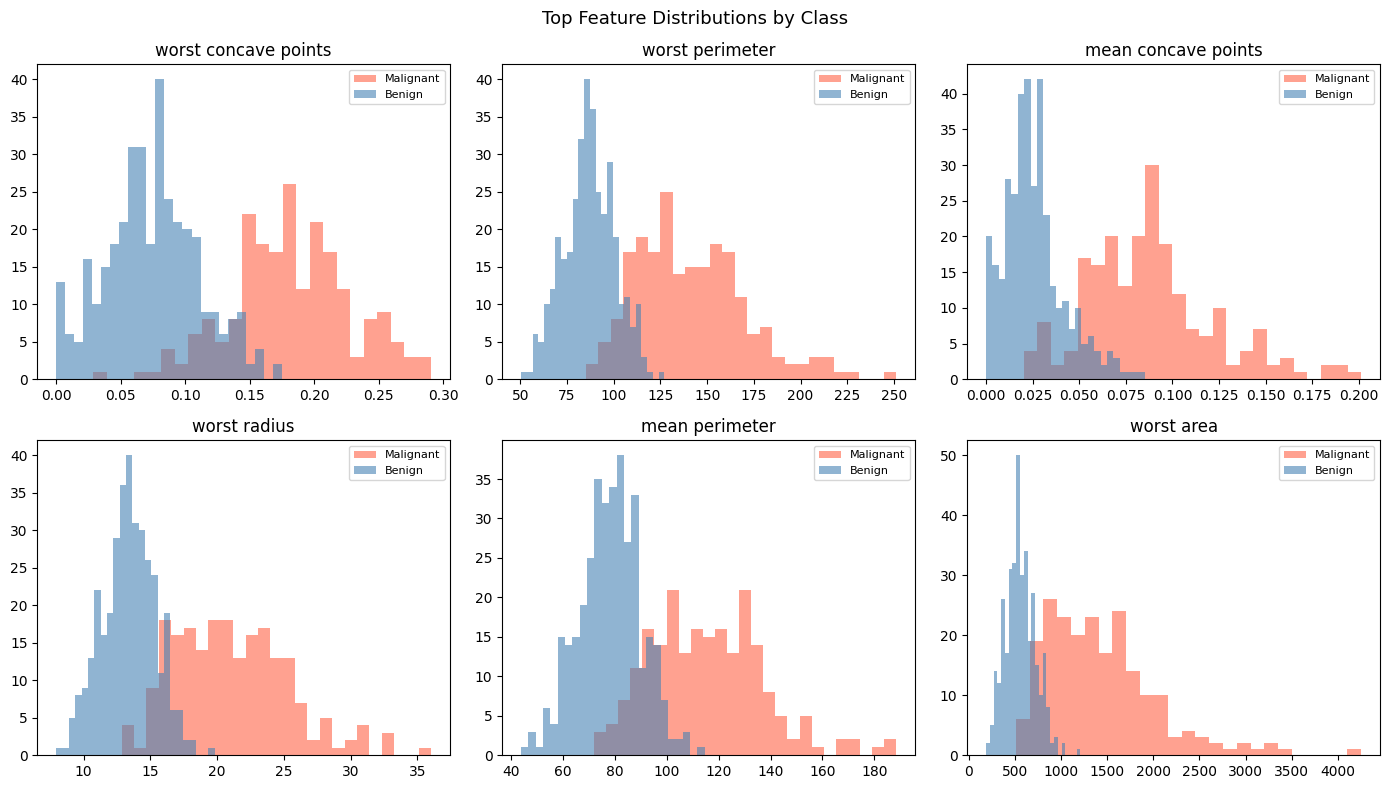

In [3]:
# Show top correlated features with target
corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('Top 10 features by correlation with target:')
print(corr.head(10))

# Plot top 6
top_features = corr.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, top_features):
    for label, name, color in [(0, 'Malignant', 'tomato'), (1, 'Benign', 'steelblue')]:
        ax.hist(df[df['target'] == label][feat], bins=25, alpha=0.6, label=name, color=color)
    ax.set_title(feat[:30])
    ax.legend(fontsize=8)
plt.suptitle('Top Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

The most predictive features are related to tumor size and shape, such as *worst concave points*, *perimeter*, and *radius*. These features show clear separation between the two classes, with malignant tumors generally exhibiting higher and more variable values compared to benign tumors. This separation supports the suitability of a linear classifier like logistic regression.

## 3. Preprocessing

In [4]:
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}, Test: {X_test_s.shape}')

Train: (455, 30), Test: (114, 30)


## 4. Training

Train accuracy: 0.9890
Test  accuracy: 0.9737


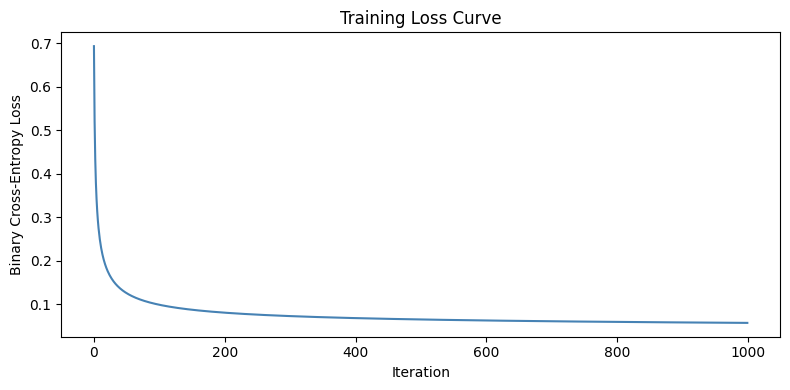

In [5]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_s, y_train)

print(f'Train accuracy: {model.score(X_train_s, y_train):.4f}')
print(f'Test  accuracy: {model.score(X_test_s, y_test):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(model.loss_history, color='steelblue')
plt.xlabel('Iteration'); plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Training Loss Curve')
plt.tight_layout()
plt.show()

## 5. Evaluation

              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



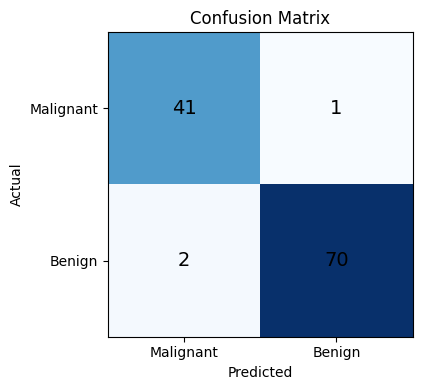

In [6]:
y_pred = model.predict(X_test_s)
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Malignant','Benign'])
ax.set_yticklabels(['Malignant','Benign'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
plt.tight_layout(); plt.show()

The confusion matrix shows the model’s prediction breakdown:

- **41 malignant cases correctly identified**
- **1 malignant case incorrectly predicted as benign (false negative)**
- **70 benign cases correctly identified**
- **2 benign cases incorrectly predicted as malignant (false positives)**

Importantly, the model has a **very low false negative rate**, which is critical in medical diagnosis since missing a malignant tumor is the most serious type of error.

## 6. ROC Curve & AUC

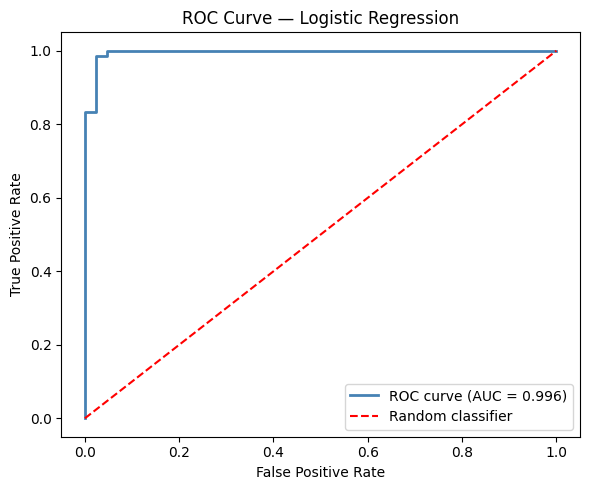

In [7]:
y_probs = model.predict_proba(X_test_s)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'r--', label='Random classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

ROC AUC measures how well the model separates the two classes across all classification thresholds:

- The ROC curve plots **True Positive Rate vs False Positive Rate**
- **AUC (Area Under the Curve)** summarizes this performance:
  - 1.0 = perfect classification
  - 0.5 = random guessing

Based on the ROC curve above, we notice excellent classification performance across all thresholds.

- The curve stays very close to the top-left corner, indicating a strong tradeoff between sensitivity and specificity.
- The **AUC of 0.996** confirms that the model almost perfectly distinguishes between malignant and benign tumors regardless of the decision threshold.

## 7. Effect of Decision Threshold

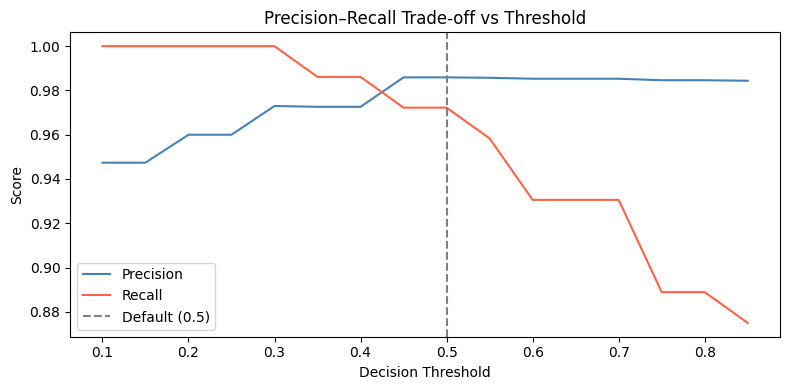

In [8]:
from sklearn.metrics import precision_score, recall_score

thresholds_to_try = np.arange(0.1, 0.9, 0.05)
precisions, recalls = [], []

for t in thresholds_to_try:
    preds = (y_probs >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds, zero_division=0))

plt.figure(figsize=(8, 4))
plt.plot(thresholds_to_try, precisions, label='Precision', color='steelblue')
plt.plot(thresholds_to_try, recalls, label='Recall', color='tomato')
plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)')
plt.xlabel('Decision Threshold'); plt.ylabel('Score')
plt.title('Precision–Recall Trade-off vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

The plot above shows how **precision** and **recall** change as the decision threshold of a logistic regression model is adjusted.

- **Precision (blue)** slightly increases as the threshold rises. This means that when the model is more conservative (higher threshold), its positive predictions are more accurate.
- **Recall (red)** decreases as the threshold increases. A higher threshold causes the model to miss more actual positive cases.

#### Key Observations:
- **Low thresholds (≈0.1–0.3):**
  - Recall is very high (~1.0)
  - Precision is slightly lower  
  → The model captures almost all positive cases but includes more false positives.

- **High thresholds (≈0.7–0.85):**
  - Precision remains high
  - Recall drops significantly  
  → The model makes fewer false positive errors but misses more true cases.

- **Default threshold (0.5):**
  - Precision ≈ 0.985
  - Recall ≈ 0.97  
  → Provides a balanced trade-off between precision and recall.

## 8. Key Takeaways

- Logistic Regression achieves >95% accuracy on breast cancer classification, which is strong for a linear model.
- The **ROC-AUC** near 1.0 confirms the model ranks positives well above negatives across all thresholds.
- In medical contexts, **recall (sensitivity)** for malignant cases matters more than precision. A missed cancer is far worse than a false alarm. Lowering the threshold increases recall at the cost of precision.
- **Standardization is critical** which is why features like `mean area` and `mean radius` span very different scales.

## Why Logistic Regression?

Logistic regression is well-suited for this dataset because the task is a **binary classification problem**, where the goal is to predict whether a tumor is **malignant or benign** based on a set of numerical features extracted from cell images.

The model works well in this setting because it estimates the probability of a sample belonging to one of two classes using a sigmoid function. This makes it naturally interpretable for medical decision-making, where outputs can be viewed as risk probabilities rather than hard labels.

Additionally, the dataset contains relatively well-behaved, continuous features that often show approximately linear relationships with the log-odds of the target variable. Logistic regression performs strongly under these conditions and provides a strong baseline model that is both efficient and easy to interpret compared to more complex classifiers.